# Phase 4c — Multi-Horizon Forecasting: next day, next month, next year

Extends the returns-target LSTM (Phase 4b) from next-*day* to three horizons:

| Horizon | Trading days ahead | Target |
|---|---|---|
| Next day | 1 | `P(t+1)/P(t) − 1` |
| Next month | 21 | `P(t+21)/P(t) − 1` |
| Next year | 252 | `P(t+252)/P(t) − 1` |

Predicted return is reconstructed to a price (`today × (1 + r)`) so metrics
stay comparable. Baselines per horizon: **naive** (price unchanged) and
**linear regression** on today's 9 engineered features.

### Two honesty-critical design points

**1. Purged splits.** With an *h*-day-ahead target, the last *h* rows of the
training period have targets realised *inside* the validation window (and
likewise val → test). Training on them leaks future information across the
split boundary. We therefore **purge the last *h* rows of train and of val**
before fitting anything (standard practice in financial ML, cf. de Prado).

**2. The next-year horizon is only weakly evaluable with 5 years of data.**
- After purging 252 rows, the ~140-row validation split vanishes entirely →
  **no early stopping** at this horizon; we train a fixed 30 epochs instead.
- Adjacent training targets overlap by 251 of 252 days, so the ~400 usable
  training rows contain far less independent information than they appear to
  — closer to ~2 non-overlapping annual observations.
- **JIOFIN** (listed Aug-2023) has too little history and is skipped at this
  horizon (logged below).
- Directional accuracy needs context at long horizons: Indian large-caps
  mostly *rose* over any 1-year window in this sample, so we also report the
  trivial **"always up"** accuracy as the bar to clear — a model is only
  interesting directionally if it beats that, not just 50%.

Everything else — features, architecture, chronological ordering, metrics —
is identical to Phases 4/4b.

In [1]:
# CRITICAL: tensorflow before pandas/sklearn (see src/lstm_model.py docstring).
import tensorflow as tf
tf.random.set_seed(42)

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_universe, flat_tickers, ticker_to_sector
from src.features import FEATURE_COLUMNS
from src.scaling import chronological_split, scale_features
from src.evaluate import compute_metrics
from src.lstm_model import (
    build_sequences, build_sequences_for_split,
    build_lstm_model, train_lstm, reconstruct_price_from_returns,
)
from sklearn.preprocessing import StandardScaler

RESULTS_DIR = ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
PROCESSED_DIR = ROOT / "data" / "processed"
HORIZON_PRED_DIR = RESULTS_DIR / "predictions_horizons"

HORIZONS = {"next_day": 1, "next_month": 21, "next_year": 252}
SEQ_LENGTH = 30
MIN_TRAIN_SEQUENCES = 100   # skip a stock/horizon below this (logged)
FIXED_EPOCHS_NO_VAL = 30    # when purging leaves no usable validation split

np.random.seed(42)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")
print("Repo root:", ROOT, "| TF", tf.__version__)

Repo root: /Users/pranav/Documents/GitHub/stock-lstm-forecast | TF 2.21.0


In [2]:
universe = load_universe()
tickers = flat_tickers(universe)
tk2sec = ticker_to_sector(universe)
print(f"{len(tickers)} tickers, horizons: {HORIZONS}")

40 tickers, horizons: {'next_day': 1, 'next_month': 21, 'next_year': 252}


## 1. Per-stock, per-horizon pipeline

For each (stock, horizon): build the h-day return target, split
chronologically, **purge** the last h rows of train and val, scale (train-only
fit, features and target), train the LSTM (early stopping where a purged val
split survives, fixed epochs otherwise), and evaluate naive / linear
regression / LSTM on identical test rows.

In [3]:
def run_one(tk: str, horizon_name: str, h: int):
    '''Returns (result_row, predictions_df, forward_forecast) or (skip_reason, None, None).'''
    feats = pd.read_csv(PROCESSED_DIR / f"{tk.replace('.', '_')}.csv",
                        index_col="Date", parse_dates=True)
    adj = feats["Adj Close"]
    feats["target_return"] = adj.shift(-h) / adj - 1.0
    feats["target_price"] = adj.shift(-h)
    feats = feats.dropna(subset=["target_return", "target_price"])
    if len(feats) < 200:
        return f"only {len(feats)} usable rows after {h}-day target", None, None

    train, val, test = chronological_split(feats, 0.70, 0.15)
    train_s, val_s, test_s, _ = scale_features(train, val, test, FEATURE_COLUMNS)

    # PURGE: drop the last h rows of train and val — their targets are
    # realised inside the following split's time window (leakage otherwise).
    train_p, val_p = train_s.iloc[:-h] if h < len(train_s) else train_s.iloc[0:0], \
                     val_s.iloc[:-h] if h < len(val_s) else val_s.iloc[0:0]

    if len(train_p) - (SEQ_LENGTH - 1) < MIN_TRAIN_SEQUENCES:
        return (f"{len(train_p)} purged train rows -> "
                f"<{MIN_TRAIN_SEQUENCES} sequences"), None, None

    # Target scaler fit on PURGED train targets only.
    t_scaler = StandardScaler()
    train_p = train_p.assign(target_scaled=t_scaler.fit_transform(
        train_p[["target_return"]]).flatten())
    test_sc = test_s.assign(target_scaled=t_scaler.transform(
        test_s[["target_return"]]).flatten())

    X_train, Y_train, _ = build_sequences(train_p, FEATURE_COLUMNS,
                                           "target_scaled", SEQ_LENGTH)

    use_early_stopping = len(val_p) >= SEQ_LENGTH + 10
    model = build_lstm_model((SEQ_LENGTH, len(FEATURE_COLUMNS)))
    if use_early_stopping:
        val_sc = val_p.assign(target_scaled=t_scaler.transform(
            val_p[["target_return"]]).flatten())
        X_val, Y_val, _ = build_sequences_for_split(
            train_p, val_sc, FEATURE_COLUMNS, "target_scaled", SEQ_LENGTH)
        model, hist = train_lstm(model, X_train, Y_train, X_val, Y_val,
                                  epochs=100, patience=10)
    else:
        hist = model.fit(X_train, Y_train, epochs=FIXED_EPOCHS_NO_VAL,
                          batch_size=32, verbose=0)

    # Test sequences: lookback buffer from full pre-test history (features are
    # realised past data — purging concerns targets, not lookback features).
    pre_test = pd.concat([train_s, val_s]).assign(target_scaled=0.0)
    X_test, _, test_dates = build_sequences_for_split(
        pre_test, test_sc, FEATURE_COLUMNS, "target_scaled", SEQ_LENGTH)

    pred_ret = t_scaler.inverse_transform(
        model.predict(X_test, verbose=0).reshape(-1, 1)).flatten()
    today = test["Adj Close"].values
    lstm_price = reconstruct_price_from_returns(today, pred_ret)

    # Baselines on identical test rows.
    naive_price = today.copy()                       # price unchanged
    linreg = LinearRegression().fit(
        train_p[FEATURE_COLUMNS], train_p["target_return"])
    lr_price = reconstruct_price_from_returns(
        today, linreg.predict(test_s[FEATURE_COLUMNS]))

    y_true, y_prev = test["target_price"], test["Adj Close"]
    m_lstm = compute_metrics(y_true, lstm_price, y_prev)
    m_naive = compute_metrics(y_true, naive_price, y_prev)
    m_lr = compute_metrics(y_true, lr_price, y_prev)
    always_up = float((test["target_return"] > 0).mean() * 100)

    row = {"ticker": tk, "sector": tk2sec[tk], "horizon": horizon_name,
           "h_days": h, "early_stopping": use_early_stopping,
           "epochs": len(hist.history["loss"]),
           "always_up_acc": round(always_up, 1)}
    for name, m in [("naive", m_naive), ("linreg", m_lr), ("lstm", m_lstm)]:
        row[f"{name}_RMSE"] = m["rmse"]
        row[f"{name}_MAPE"] = m["mape"]
        row[f"{name}_DirAcc"] = m["directional_accuracy"]

    preds = pd.DataFrame({"date": test_dates, "actual": y_true.values,
                           "naive": naive_price,
                           "linreg": lr_price, "lstm": lstm_price})

    # FORWARD forecast from the latest available data (for the app's chart).
    # Note the h-day targets were dropped from the frame's tail by dropna, so
    # rebuild the latest feature window from the untruncated processed CSV,
    # scaled with the SAME train-fitted feature scaler used above.
    full = pd.read_csv(PROCESSED_DIR / f"{tk.replace('.', '_')}.csv",
                        index_col="Date", parse_dates=True)
    feat_scaler = StandardScaler().fit(train[FEATURE_COLUMNS])
    latest = full[FEATURE_COLUMNS].tail(SEQ_LENGTH)
    X_latest = feat_scaler.transform(latest).reshape(1, SEQ_LENGTH, -1)
    fwd_ret = float(t_scaler.inverse_transform(
        model.predict(X_latest, verbose=0).reshape(-1, 1))[0, 0])
    last_date = full.index[-1]
    last_price = float(full["Adj Close"].iloc[-1])
    forecast = {
        "ticker": tk, "horizon": horizon_name, "h_days": h,
        "as_of_date": last_date.date().isoformat(),
        "last_price": round(last_price, 2),
        "pred_return_pct": round(fwd_ret * 100, 3),
        "pred_price": round(last_price * (1 + fwd_ret), 2),
        "target_date": (last_date + pd.tseries.offsets.BDay(h)).date().isoformat(),
    }
    return row, preds, forecast

In [4]:
all_rows, skipped, forecasts = [], [], []
t_all = time.time()

for horizon_name, h in HORIZONS.items():
    out_dir = HORIZON_PRED_DIR / horizon_name
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n===== {horizon_name} (h={h}) =====")
    t_h = time.time()
    for i, tk in enumerate(tickers, 1):
        res, preds, fwd = run_one(tk, horizon_name, h)
        if preds is None:
            skipped.append({"ticker": tk, "horizon": horizon_name, "reason": res})
            print(f"  [{i:>2}/40] {tk:<16} SKIPPED: {res}")
            continue
        all_rows.append(res)
        forecasts.append(fwd)
        preds.to_csv(out_dir / f"{tk.replace('.', '_')}.csv", index=False)
        es = "ES" if res["early_stopping"] else f"fixed{res['epochs']}"
        print(f"  [{i:>2}/40] {tk:<16} {es:<8} MAPE={res['lstm_MAPE']:.2f}%  "
              f"DirAcc={res['lstm_DirAcc']:.1f}% (always-up {res['always_up_acc']}%)")
    print(f"  -- {horizon_name} done in {time.time()-t_h:.0f}s")

print(f"\nTotal: {len(all_rows)} (stock,horizon) runs in {time.time()-t_all:.0f}s; "
      f"{len(skipped)} skipped.")


===== next_day (h=1) =====


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [ 1/40] TCS.NS           ES       MAPE=1.24%  DirAcc=45.8% (always-up 45.8%)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [ 2/40] INFY.NS          ES       MAPE=1.38%  DirAcc=45.3% (always-up 44.1%)


...

  [38/40] TATACONSUM.NS    fixed30  MAPE=22.18%  DirAcc=23.4% (always-up 92.9%)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [39/40] DABUR.NS         fixed30  MAPE=14.85%  DirAcc=17.7% (always-up 21.3%)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [40/40] COLPAL.NS        fixed30  MAPE=97.95%  DirAcc=0.0% (always-up 0.0%)
  -- next_year done in 213s

Total: 119 (stock,horizon) runs in 634s; 1 skipped.


### Skipped (stock, horizon) pairs — documented, not hidden

In [5]:
if skipped:
    print(pd.DataFrame(skipped).to_string(index=False))
else:
    print("No skips — every stock trained at every horizon.")

   ticker   horizon                                 reason
JIOFIN.NS next_year 37 purged train rows -> <100 sequences


## 2. Results by horizon

In [6]:
mh = pd.DataFrame(all_rows)
mh.to_csv(RESULTS_DIR / "multi_horizon_comparison.csv", index=False)
fc = pd.DataFrame(forecasts)
fc.to_csv(RESULTS_DIR / "latest_forecasts.csv", index=False)
print("Saved", RESULTS_DIR / "latest_forecasts.csv", f"({len(fc)} forward forecasts, "
      f"as of {fc['as_of_date'].max()})")
print("Saved", RESULTS_DIR / "multi_horizon_comparison.csv", f"({len(mh)} rows)\n")

summary = mh.groupby("horizon").agg(
    n_stocks=("ticker", "count"),
    naive_MAPE=("naive_MAPE", "mean"), linreg_MAPE=("linreg_MAPE", "mean"),
    lstm_MAPE=("lstm_MAPE", "mean"),
    naive_DirAcc=("naive_DirAcc", "mean"), linreg_DirAcc=("linreg_DirAcc", "mean"),
    lstm_DirAcc=("lstm_DirAcc", "mean"), always_up=("always_up_acc", "mean"),
).round(2).reindex(["next_day", "next_month", "next_year"])
print(summary.to_string())

Saved /Users/pranav/Documents/GitHub/stock-lstm-forecast/results/latest_forecasts.csv (119 forward forecasts, as of 2026-07-10)
Saved /Users/pranav/Documents/GitHub/stock-lstm-forecast/results/multi_horizon_comparison.csv (119 rows)

            n_stocks  naive_MAPE  linreg_MAPE  lstm_MAPE  naive_DirAcc  linreg_DirAcc  lstm_DirAcc  always_up
horizon                                                                                                      
next_day          40        1.25         1.30       1.27          2.57          49.33        49.21      48.19
next_month        40        6.39         8.09       8.00          0.06          51.03        49.67      50.37
next_year         39       17.56        83.17      34.74          0.00          61.34        62.48      54.63


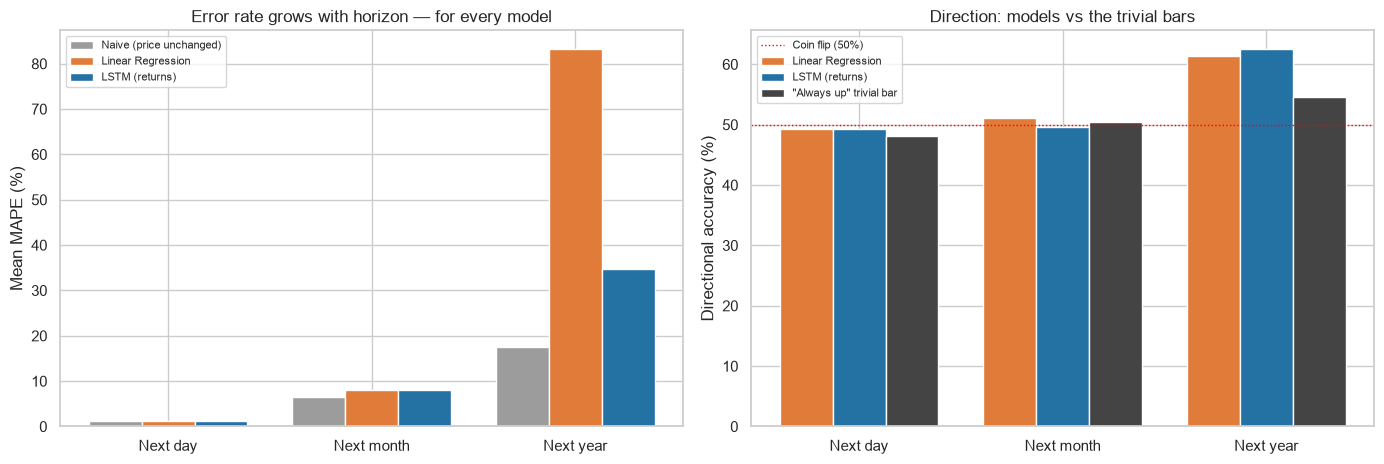

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(3)
w = 0.26
order = ["next_day", "next_month", "next_year"]
for j, (col, label, color) in enumerate([
        ("naive_MAPE", "Naive (price unchanged)", "#9c9c9c"),
        ("linreg_MAPE", "Linear Regression", "#e07b39"),
        ("lstm_MAPE", "LSTM (returns)", "#2471a3")]):
    axes[0].bar(x + (j-1)*w, summary.loc[order, col], w, label=label, color=color)
axes[0].set_xticks(x, ["Next day", "Next month", "Next year"])
axes[0].set_ylabel("Mean MAPE (%)")
axes[0].set_title("Error rate grows with horizon — for every model")
axes[0].legend(fontsize=8)

for j, (col, label, color) in enumerate([
        ("linreg_DirAcc", "Linear Regression", "#e07b39"),
        ("lstm_DirAcc", "LSTM (returns)", "#2471a3"),
        ("always_up", '"Always up" trivial bar', "#444444")]):
    axes[1].bar(x + (j-1)*w, summary.loc[order, col], w, label=label, color=color)
axes[1].axhline(50, color="red", linestyle=":", linewidth=1, label="Coin flip (50%)")
axes[1].set_xticks(x, ["Next day", "Next month", "Next year"])
axes[1].set_ylabel("Directional accuracy (%)")
axes[1].set_title("Direction: models vs the trivial bars")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "multi_horizon_summary.png", dpi=110)
plt.show()

## 3. Example: one stock across all three horizons

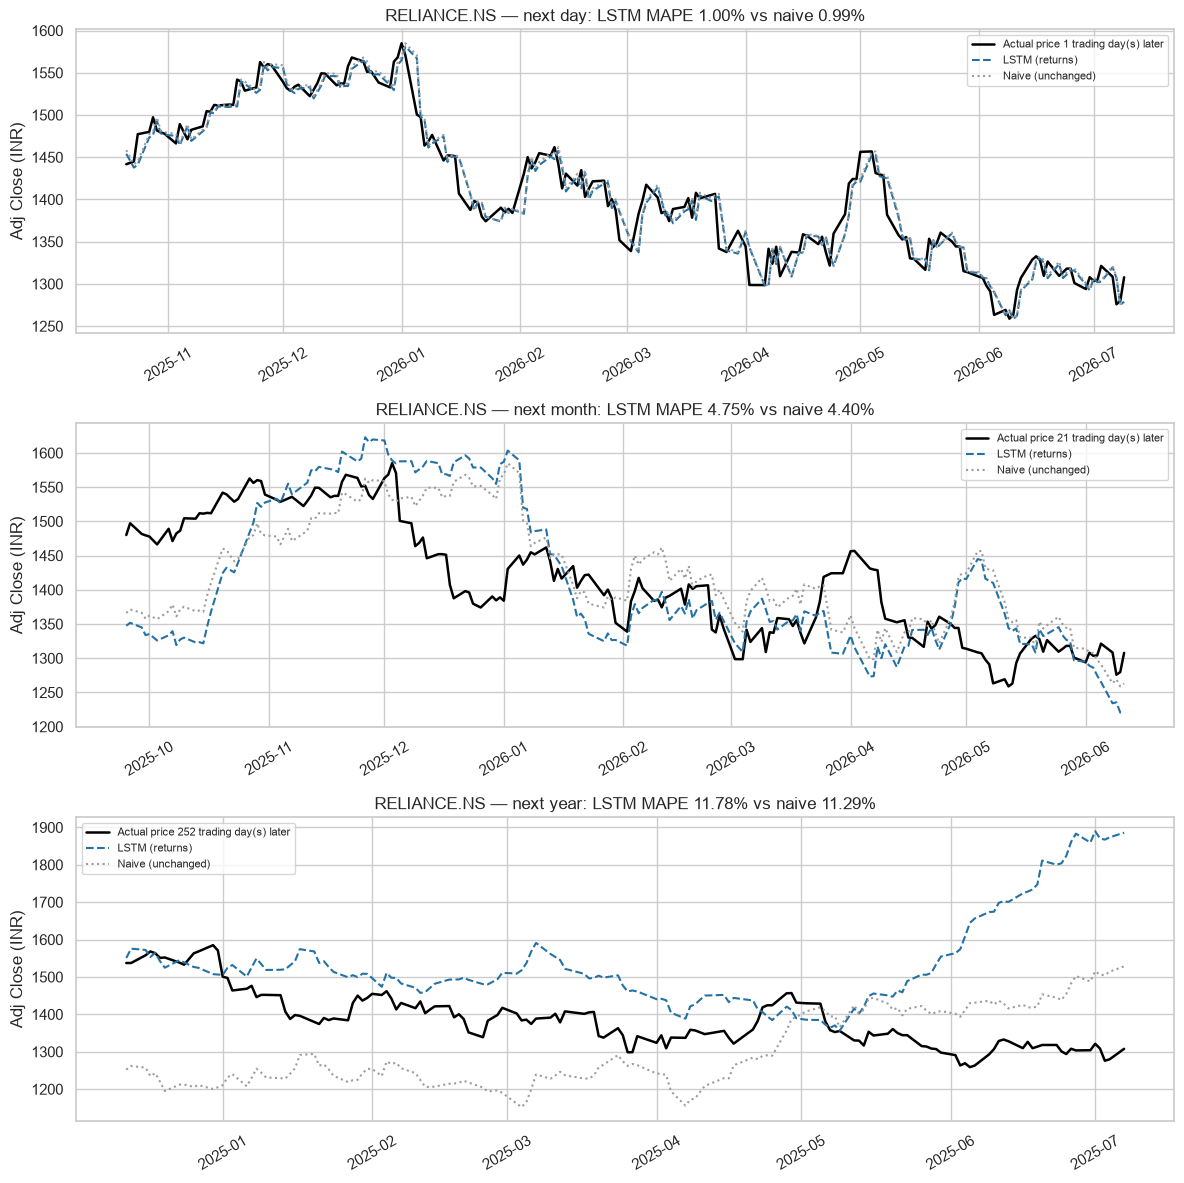

In [8]:
example = "RELIANCE.NS"
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
for ax, hname in zip(axes, order):
    p = pd.read_csv(HORIZON_PRED_DIR / hname / f"{example.replace('.', '_')}.csv",
                    parse_dates=["date"])
    ax.plot(p["date"], p["actual"], color="black", linewidth=1.8,
            label=f"Actual price {HORIZONS[hname]} trading day(s) later")
    ax.plot(p["date"], p["lstm"], "--", color="#2471a3", label="LSTM (returns)")
    ax.plot(p["date"], p["naive"], ":", color="#9c9c9c", label="Naive (unchanged)")
    row = mh[(mh.ticker == example) & (mh.horizon == hname)].iloc[0]
    ax.set_title(f"{example} — {hname.replace('_', ' ')}: LSTM MAPE "
                 f"{row['lstm_MAPE']:.2f}% vs naive {row['naive_MAPE']:.2f}%")
    ax.set_ylabel("Adj Close (INR)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "multi_horizon_example.png", dpi=110)
plt.show()

## 4. Honest verdict, per horizon

In [9]:
print("=" * 74)
print("MULTI-HORIZON VERDICT")
print("=" * 74)
for hname in order:
    s = summary.loc[hname]
    print(f"\n[{hname.replace('_', ' ').upper()}]  ({int(s['n_stocks'])} stocks)")
    print(f"  Error rate: LSTM {s['lstm_MAPE']:.2f}% vs naive {s['naive_MAPE']:.2f}% "
          f"vs linreg {s['linreg_MAPE']:.2f}% MAPE")
    beat_naive = s["lstm_MAPE"] < s["naive_MAPE"]
    print(f"  -> LSTM {'BEATS' if beat_naive else 'does NOT beat'} the "
          f"price-unchanged baseline on error.")
    print(f"  Direction: LSTM {s['lstm_DirAcc']:.1f}% vs linreg "
          f"{s['linreg_DirAcc']:.1f}% vs always-up {s['always_up']:.1f}%")
    bar = max(50.0, s["always_up"])
    edge = s["lstm_DirAcc"] - bar
    print(f"  -> vs the harder trivial bar ({bar:.1f}%): {edge:+.1f}pp "
          f"{'(no real edge)' if abs(edge) <= 3 else ''}")

print("\nCaveats that stand regardless of the numbers above:")
print("  * next_year: no early stopping (purging consumed the val split), "
      "~2 effective non-overlapping annual observations per stock, JIOFIN "
      "skipped. Treat as illustrative, not as a validated forecast.")
print("  * Longer horizons inherit trend: in a mostly-rising sample, 'always "
      "up' is the bar, and beating 50% alone means little.")

MULTI-HORIZON VERDICT

[NEXT DAY]  (40 stocks)
  Error rate: LSTM 1.27% vs naive 1.25% vs linreg 1.30% MAPE
  -> LSTM does NOT beat the price-unchanged baseline on error.
  Direction: LSTM 49.2% vs linreg 49.3% vs always-up 48.2%
  -> vs the harder trivial bar (50.0%): -0.8pp (no real edge)

[NEXT MONTH]  (40 stocks)
  Error rate: LSTM 8.00% vs naive 6.39% vs linreg 8.09% MAPE
  -> LSTM does NOT beat the price-unchanged baseline on error.
  Direction: LSTM 49.7% vs linreg 51.0% vs always-up 50.4%
  -> vs the harder trivial bar (50.4%): -0.7pp (no real edge)

[NEXT YEAR]  (39 stocks)
  Error rate: LSTM 34.74% vs naive 17.56% vs linreg 83.17% MAPE
  -> LSTM does NOT beat the price-unchanged baseline on error.
  Direction: LSTM 62.5% vs linreg 61.3% vs always-up 54.6%
  -> vs the harder trivial bar (54.6%): +7.8pp 

Caveats that stand regardless of the numbers above:
  * next_year: no early stopping (purging consumed the val split), ~2 effective non-overlapping annual observations per sto